# Projeto Computacional de Mecânica Clássica

In [55]:
from __future__ import annotations

from dataclasses import dataclass
from math import cos
from pathlib import Path
from typing import Any, Literal

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

from utils.linear_algebra import Vec3
from utils.particle import ForceFunc, Particle

## Partícula
#### $$\begin{aligned}P(m, \vec r, \vec v), \quad & \vec r = \begin{bmatrix}x\\y\\z\end{bmatrix}, \vec v = \begin{bmatrix}v_x\\v_y\\v_z\end{bmatrix}\end{aligned}.$$

## Forças
#### $$\vec F = \frac{d (m\vec v)}{dt}$$

### Força Restauradora Não Linear
#### $$\vec F_r = -\left(k + \alpha|\vec r|^2\right)\vec r\qquad k,\alpha\in\mathbb{R}$$

In [56]:
K = 1.0         # [N/m]  Constante elástica linear
ALPHA = 0.5     # [N/m³] Intensidade da não linearidade

def restoring_force(k: float = K, alpha: float = ALPHA) -> ForceFunc:
    def f(particle: Particle, _: float | None = None) -> Vec3:
        r = particle.position.length()
        return particle.position * -(k + alpha * (r ** 2))
    return f

### Força de Amortecimento
#### $$\vec F_d = -b\vec v$$

In [57]:
B = 0.3         # [kg/s] Coeficiente de amortecimento

def damping_force(b: float = B) -> ForceFunc:
    def f(particle: Particle, _: float | None = None) -> Vec3:
        return particle.velocity * (-b)
    return f

### Força Externa Periódica
#### $$\vec F_\text{ext} = \vec F_0\cos(\omega t + \phi)$$

In [58]:
F0 = 0.5        # [N]      Amplitude da força externa
OMEGA = 0.7     # [rad/s]  Frequência angular da excitação externa (ω₀ = 1.0 rad/s)
PHI = 0.0       # [rad]    Fase inicial

def external_periodic_force(
    f_o: Vec3 | None = None,
    omega: float = OMEGA,
    phi: float = PHI,
) -> ForceFunc:
    _f_o = f_o or Vec3(F0, 0.0, 0.0)
    def f(_: Particle, time: float | None = None) -> Vec3:
        if time is None:
            return Vec3(0.0, 0.0, 0.0)
        return _f_o * cos(omega * time + phi)
    return f

## Simulação

In [59]:
## Parâmetros de simulação
MASS = 1.0                              # [kg]
X0 = 1.0                                # [m]   posição inicial padrão
V0 = 0.0                                # [m/s] velocidade inicial padrão
T_MAX = 80.0                            # [s]
TIME_STEP = 0.01                        # [s]


@dataclass
class OscillatorMetrics:
    x_max: float          # [m]  Amplitude máxima durante toda a simulação
    x_steady: float       # [m]  Amplitude máxima no regime estacionário (últimos 25%)
    e_initial: float      # [J]  Energia mecânica inicial
    e_final: float        # [J]  Energia mecânica final
    e_steady_mean: float  # [J]  Energia média no regime estacionário


@dataclass
class OscillatorResults:
    times: np.ndarray       # shape (N,)    [s]
    positions: np.ndarray   # shape (N, 3)  [m]   — apenas [:, 0] (x) é usado
    velocities: np.ndarray  # shape (N, 3)  [m/s] — apenas [:, 0] (vx) é usado
    energies: np.ndarray    # shape (N,)    [J]   energia mecânica
    p_ext: np.ndarray       # shape (N,)    [W]   potência da força externa
    p_diss: np.ndarray      # shape (N,)    [W]   potência dissipada
    metrics: OscillatorMetrics


def oscillator_mechanical_energy(
    particle: Particle,
    k: float, alpha: float
) -> float:
    r = particle.position.length() # Considerando a mola fixa na origem
    energia_elastica = 0.5 * k * r**2 + 0.25 * alpha * r**4
    energia_cinetica = particle.kinetic_energy()
    return energia_cinetica + energia_elastica


def extract_oscillator_metrics(
    times: np.ndarray,
    positions: np.ndarray,
    velocities: np.ndarray,
    energies: np.ndarray,
) -> OscillatorMetrics:
    x = positions[:, 0]
    x_max = float(np.max(np.abs(x)))

    steady_start = int(0.75 * len(times))
    x_steady = float(np.max(np.abs(x[steady_start:])))

    e_initial = float(energies[0])
    e_final = float(energies[-1])
    e_steady_mean = float(np.mean(energies[steady_start:]))

    return OscillatorMetrics(
        x_max=x_max,
        x_steady=x_steady,
        e_initial=e_initial,
        e_final=e_final,
        e_steady_mean=e_steady_mean,
    )


def simulate_oscillator(
    x0: float = X0,
    v0: float = V0,
    mass: float = MASS,
    k: float = K,
    alpha: float = ALPHA,
    b: float = B,
    f0: float = F0,
    omega: float = OMEGA,
    t_max: float = T_MAX,
    dt: float = TIME_STEP,
    with_damping: bool = True,
    with_external: bool = True,
    simulation_type: Literal["Euler", "RK4"] = "RK4",
) -> OscillatorResults:
    particle = Particle(
        mass=mass,
        position=Vec3(x0, 0.0, 0.0),
        velocity=Vec3(v0, 0.0, 0.0),
        simulation_type=simulation_type,
    )

    n_steps = int(t_max / dt)
    times      = np.empty(n_steps,       dtype=np.float64)
    positions  = np.empty((n_steps, 3),  dtype=np.float64)
    velocities = np.empty((n_steps, 3),  dtype=np.float64)
    energies   = np.empty(n_steps,       dtype=np.float64)
    p_ext_arr  = np.empty(n_steps,       dtype=np.float64)
    p_diss_arr = np.empty(n_steps,       dtype=np.float64)

    forces: list[ForceFunc] = [restoring_force(k=k, alpha=alpha)]
    if with_damping:
        forces.append(damping_force(b=b))
    if with_external:
        forces.append(external_periodic_force(f_o=Vec3(f0, 0.0, 0.0), omega=omega))

    def save_state(i: int, t: float) -> None:
        times[i] = t
        positions[i, 0] = particle.position.x
        positions[i, 1] = particle.position.y
        positions[i, 2] = particle.position.z
        velocities[i, 0] = particle.velocity.x
        velocities[i, 1] = particle.velocity.y
        velocities[i, 2] = particle.velocity.z
        vx = particle.velocity.x
        energies[i]   = oscillator_mechanical_energy(particle, k, alpha)
        p_ext_arr[i]  = (f0 * cos(omega * t) * vx) if with_external else 0.0
        p_diss_arr[i] = (-b * vx**2) if with_damping else 0.0

    t: float = 0.0
    for i in range(n_steps):
        save_state(i, t)
        particle.update(forces, dt, time=t)
        t += dt

    return OscillatorResults(
        times=times,
        positions=positions,
        velocities=velocities,
        energies=energies,
        p_ext=p_ext_arr,
        p_diss=p_diss_arr,
        metrics=extract_oscillator_metrics(times, positions, velocities, energies),
    )

### Plotagem

In [60]:
@dataclass
class OscillatorPlot:
    label: str
    result: OscillatorResults
    plot_style: dict[str, Any] | None = None


def export_figure(
    fig: plt.Figure,
    filename_stem: str,
    formats: tuple[str, ...] = ('pdf',),
    output_dir: str = 'outputs/figures',
) -> list[str]:
    folder = Path(output_dir)
    folder.mkdir(parents=True, exist_ok=True)
    exported_paths: list[str] = []
    for ext in formats:
        ext_clean = ext.lower().lstrip('.')
        file_path = folder / f'{filename_stem}.{ext_clean}'
        fig.savefig(file_path, format=ext_clean, bbox_inches='tight')
        exported_paths.append(str(file_path))
    return exported_paths


def plot_position_per_time(
    simulations: list[OscillatorPlot],
    ax: plt.Axes | None = None,
    show_legend: bool = True,
) -> tuple[plt.Figure, plt.Axes]:
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    else:
        fig = ax.figure
    for sim in simulations:
        x = sim.result.positions[:, 0]
        style = sim.plot_style or {}
        ax.plot(sim.result.times, x, label=sim.label, **style)
    ax.axhline(0.0, color='black', linewidth=0.5, alpha=0.4)
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Posição x (m)')
    ax.set_title('Posição ao longo do tempo')
    if show_legend:
        ax.legend()
    ax.grid(True, alpha=0.3)
    return fig, ax


def plot_velocity_per_time(
    simulations: list[OscillatorPlot],
    ax: plt.Axes | None = None,
    show_legend: bool = True,
) -> tuple[plt.Figure, plt.Axes]:
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    else:
        fig = ax.figure
    for sim in simulations:
        vx = sim.result.velocities[:, 0]
        style = sim.plot_style or {}
        ax.plot(sim.result.times, vx, label=sim.label, **style)
    ax.axhline(0.0, color='black', linewidth=0.5, alpha=0.4)
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Velocidade $v_x$ (m/s)')
    ax.set_title('Velocidade ao longo do tempo')
    if show_legend:
        ax.legend()
    ax.grid(True, alpha=0.3)
    return fig, ax


def _nice_tick_step(span: float, target_ticks: int = 8) -> float:
    if span <= 0:
        return 1.0
    raw_step = span / target_ticks
    exponent = np.floor(np.log10(raw_step))
    fraction = raw_step / 10**exponent
    if fraction <= 1:
        nice_fraction = 1.0
    elif fraction <= 2:
        nice_fraction = 2.0
    elif fraction <= 2.5:
        nice_fraction = 2.5
    elif fraction <= 5:
        nice_fraction = 5.0
    else:
        nice_fraction = 10.0
    return float(nice_fraction * 10**exponent)


def _apply_equal_phase_scale(ax: plt.Axes) -> None:
    from matplotlib.ticker import MultipleLocator

    ax.set_aspect('equal', adjustable='datalim')
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    tick_step = _nice_tick_step(max(x_max - x_min, y_max - y_min))
    ax.xaxis.set_major_locator(MultipleLocator(tick_step))
    ax.yaxis.set_major_locator(MultipleLocator(tick_step))


def plot_phase_portrait(
    simulations: list[OscillatorPlot],
    ax: plt.Axes | None = None,
    show_legend: bool = True,
) -> tuple[plt.Figure, plt.Axes]:
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    else:
        fig = ax.figure
    for sim in simulations:
        x  = sim.result.positions[:, 0]
        vx = sim.result.velocities[:, 0]
        style = sim.plot_style or {}
        ax.plot(x, vx, label=sim.label, **style)
    ax.set_xlabel('Posição x (m)')
    ax.set_ylabel('Velocidade $v_x$ (m/s)')
    ax.set_title('Retrato de fase')
    _apply_equal_phase_scale(ax)
    if show_legend:
        ax.legend()
    ax.grid(True, alpha=0.3)
    return fig, ax


def plot_energy_per_time(
    simulations: list[OscillatorPlot],
    ax: plt.Axes | None = None,
    show_legend: bool = True,
) -> tuple[plt.Figure, plt.Axes]:
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    else:
        fig = ax.figure
    for sim in simulations:
        style = sim.plot_style or {}
        ax.plot(sim.result.times, sim.result.energies, label=sim.label, **style)
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Energia mecânica E (J)')
    ax.set_title('Energia mecânica ao longo do tempo')
    if show_legend:
        ax.legend()
    ax.grid(True, alpha=0.3)
    return fig, ax


def plot_power_per_time(
    result: OscillatorResults,
    ax: plt.Axes | None = None,
) -> tuple[plt.Figure, plt.Axes]:
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    else:
        fig = ax.figure
    p_net = result.p_ext + result.p_diss
    ax.plot(result.times, result.p_ext,  color='C0', label=r'$P_\mathrm{ext}$')
    ax.plot(result.times, result.p_diss, color='C1', label=r'$P_\mathrm{diss}$')
    ax.plot(result.times, p_net,         color='C2', linestyle='--', label=r'$P_\mathrm{net} = \dot{E}$')
    ax.axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Potência (W)')
    ax.set_title('Balanço de potência')
    ax.legend()
    ax.grid(True, alpha=0.3)
    return fig, ax


def plot_oscillator_panels(
    simulations: list[OscillatorPlot],
    suptitle: str | None = None,
    figsize: tuple[float, float] = (13, 9),
) -> tuple[plt.Figure, np.ndarray]:
    fig, axes = plt.subplots(2, 2, figsize=figsize)

    plot_position_per_time(simulations, ax=axes[0, 0], show_legend=False)
    plot_velocity_per_time(simulations, ax=axes[0, 1], show_legend=False)
    plot_phase_portrait(simulations,   ax=axes[1, 0], show_legend=False)
    plot_energy_per_time(simulations,  ax=axes[1, 1], show_legend=False)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        ncol = min(max(1, len(handles) // 3), 6)
        fig.legend(
            handles, labels,
            loc='upper center',
            bbox_to_anchor=(0.5, -0.02),
            ncol=ncol,
            frameon=True,
            fontsize='small',
        )

    if suptitle is not None:
        fig.suptitle(suptitle, fontsize=12)

    plt.tight_layout()
    plt.show()
    return fig, axes


def plot_oscillator_metrics_from_results(
    results: list[OscillatorResults],
    x_values: list[float] | np.ndarray | None = None,
    x_label: str = 'Índice da simulação',
    x_scale: Literal['linear', 'log'] = 'linear',
    suptitle: str | None = None,
    figsize: tuple[float, float] = (12, 8),
) -> tuple[plt.Figure, np.ndarray]:
    if len(results) == 0:
        raise ValueError('A lista de OscillatorResults não pode ser vazia')

    if x_values is None:
        x = np.arange(len(results), dtype=float)
    else:
        x = np.asarray(x_values, dtype=float)
        if len(x) != len(results):
            raise ValueError('x_values deve ter o mesmo tamanho de results')

    x_max    = [r.metrics.x_max         for r in results]
    x_steady = [r.metrics.x_steady      for r in results]
    e_init   = [r.metrics.e_initial     for r in results]
    e_steady = [r.metrics.e_steady_mean for r in results]

    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True)

    axes[0, 0].plot(x, x_max,    marker='o', markersize=4, color='C0', linewidth=1.5)
    axes[0, 0].set_ylabel(r'$x_\mathrm{max}\,(m)$')
    axes[0, 0].set_title(r'Amplitude máxima $x_\mathrm{max}$')
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(x, x_steady, marker='o', markersize=4, color='C1', linewidth=1.5)
    axes[0, 1].set_ylabel(r'$x_\mathrm{est}\,(m)$')
    axes[0, 1].set_title(r'Amplitude estacionária $x_\mathrm{est}$')
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(x, e_init,   marker='o', markersize=4, color='C2', linewidth=1.5)
    axes[1, 0].set_xlabel(x_label)
    axes[1, 0].set_ylabel(r'$E_0\,(J)$')
    axes[1, 0].set_title(r'Energia inicial $E_0$')
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(x, e_steady, marker='o', markersize=4, color='C3', linewidth=1.5)
    axes[1, 1].set_xlabel(x_label)
    axes[1, 1].set_ylabel(r'$\bar{E}_\mathrm{est}\,(J)$')
    axes[1, 1].set_title(r'Energia média estacionária $\bar{E}_\mathrm{est}$')
    axes[1, 1].grid(True, alpha=0.3)

    if x_scale == 'log':
        for ax in axes.flat:
            ax.set_xscale('log')

    if suptitle is not None:
        fig.suptitle(suptitle, fontsize=12)

    fig.text(0.5, 0.02, f'Eixo horizontal: {x_label}', ha='center', fontsize=10, style='italic')
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()
    return fig, axes


def print_oscillator_metrics(metrics: OscillatorMetrics) -> None:
    print(f"Amplitude máxima (x_max):          {metrics.x_max:.4f} m")
    print(f"Amplitude estacionária (x_steady): {metrics.x_steady:.4f} m")
    print(f"Energia inicial (E_0):             {metrics.e_initial:.4f} J")
    print(f"Energia final (E_final):           {metrics.e_final:.4f} J")
    print(f"Energia média estacionária:        {metrics.e_steady_mean:.4f} J")

## Questões

### Questão 1
Discretize as equações de movimento utilizando o método de Euler com passo temporal $\Delta t$. Apresente explicitamente as expressões para $x_{n+1}$ e $v_{n+1}$.

Aplicando o **Euler** (velocidade atualizada antes da posição), a aceleração no instante $t_n$ é:

$$a_n = -\frac{k}{m}x_n - \frac{\alpha}{m}x_n^3 - \frac{b}{m}v_n + \frac{F_0}{m}\cos(\omega t_n)$$

A atualização a cada passo $n \to n+1$:

$$\boxed{v_{n+1} = v_n + a_n\,\Delta t}$$

$$\boxed{x_{n+1} = x_n + v_{n+1}\,\Delta t}$$

### Questão 2
Faça uma análise gráfica do potencial efetivo $U(x)$ para diferentes valores de $\alpha$. Discuta como a não linearidade modifica a forma do potencial.

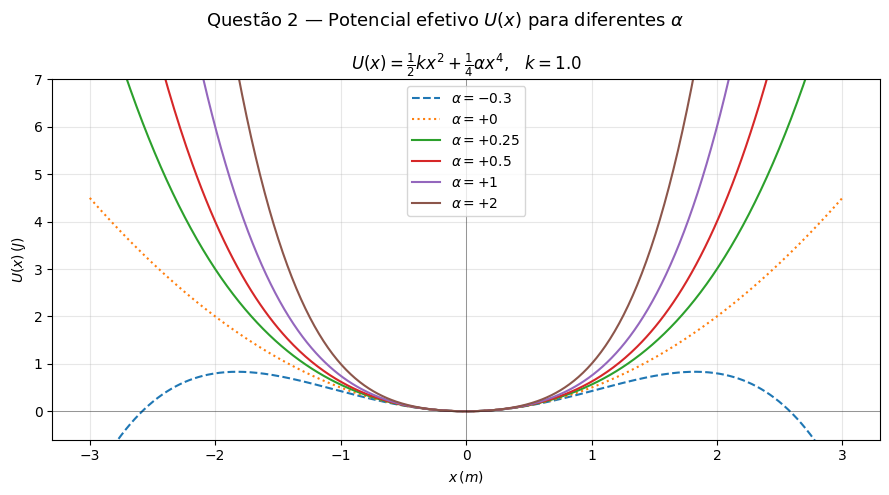

['outputs\\figures\\questao2_potencial.pdf']

In [61]:
# Questão 2: análise gráfica do potencial efetivo U(x) para diferentes α
x_pot = np.linspace(-3.0, 3.0, 500)


def potential_energy(x: np.ndarray, k: float, alpha: float) -> np.ndarray:
    return 0.5 * k * x**2 + 0.25 * alpha * x**4


alpha_values_q2 = [-0.3, 0.0, 0.25, 0.5, 1.0, 2.0]

fig_q2, ax_q2 = plt.subplots(figsize=(9, 5))

for alpha_val in alpha_values_q2:
    U = potential_energy(x_pot, K, alpha_val)
    style = '--' if alpha_val < 0 else ('-' if alpha_val > 0 else ':')
    ax_q2.plot(x_pot, U, linestyle=style, label=rf'$\alpha = {alpha_val:+.2g}$')

ax_q2.set_ylim(-0.6, 7.0)
ax_q2.axhline(0.0, color='black', linewidth=0.5, alpha=0.5)
ax_q2.axvline(0.0, color='black', linewidth=0.5, alpha=0.5)
ax_q2.set_xlabel(r'$x\,(m)$')
ax_q2.set_ylabel(r'$U(x)\,(J)$')
ax_q2.set_title(rf'$U(x) = \frac{{1}}{{2}}kx^2 + \frac{{1}}{{4}}\alpha x^4$,   $k = {K}$')
ax_q2.legend()
ax_q2.grid(True, alpha=0.3)

fig_q2.suptitle(r'Questão 2 — Potencial efetivo $U(x)$ para diferentes $\alpha$', fontsize=13)
fig_q2.tight_layout()
plt.show()

export_figure(fig_q2, 'questao2_potencial')

### Questão 3
Implemente o método numérico e obtenha numericamente as soluções $x(t)$ e $v(t)$, bem como o retrato de fase $v \times x$. Discuta o comportamento físico observado.

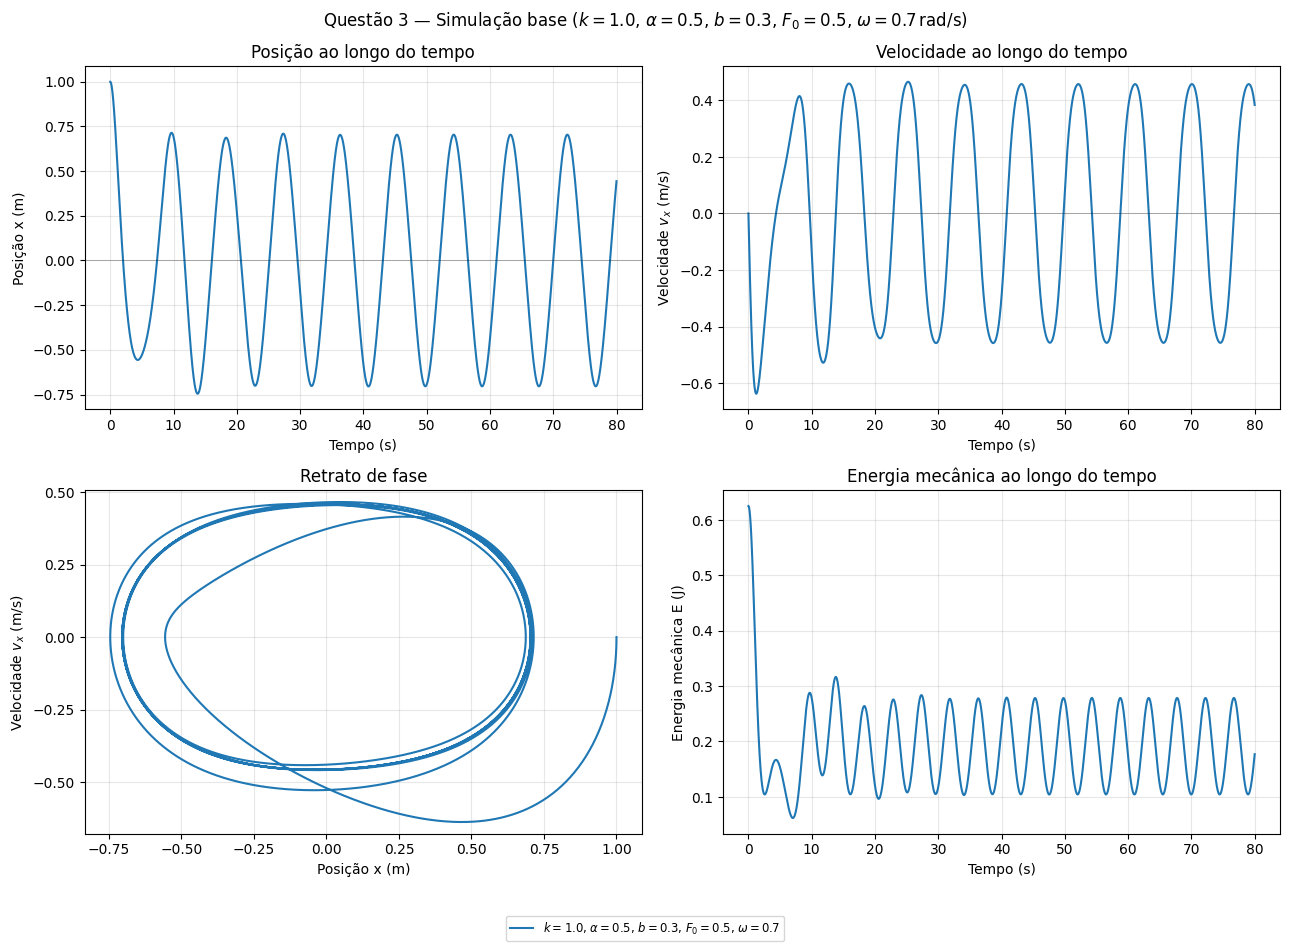

Amplitude máxima (x_max):          1.0000 m
Amplitude estacionária (x_steady): 0.7040 m
Energia inicial (E_0):             0.6250 J
Energia final (E_final):           0.1771 J
Energia média estacionária:        0.1828 J


In [62]:
# Questão 3: simulação com parâmetros padrão (todas as forças ativas)
result_q3 = simulate_oscillator()

sims_q3 = [
    OscillatorPlot(
        label=rf'$k={K}$, $\alpha={ALPHA}$, $b={B}$, $F_0={F0}$, $\omega={OMEGA}$',
        result=result_q3,
    )
]

fig_q3, axes_q3 = plot_oscillator_panels(
    sims_q3,
    suptitle=(
        rf'Questão 3 — Simulação base'
        rf' ($k={K}$, $\alpha={ALPHA}$, $b={B}$, $F_0={F0}$, $\omega={OMEGA}\,$rad/s)'
    ),
)

export_figure(fig_q3, 'questao3_simulacao_base')
print_oscillator_metrics(result_q3.metrics)

### Questão 4
Considere o caso sem força externa ($F_0 = 0$). Analise como diferentes valores do coeficiente de amortecimento $b$ influenciam a amplitude das oscilações, o decaimento temporal e o retrato de fase.

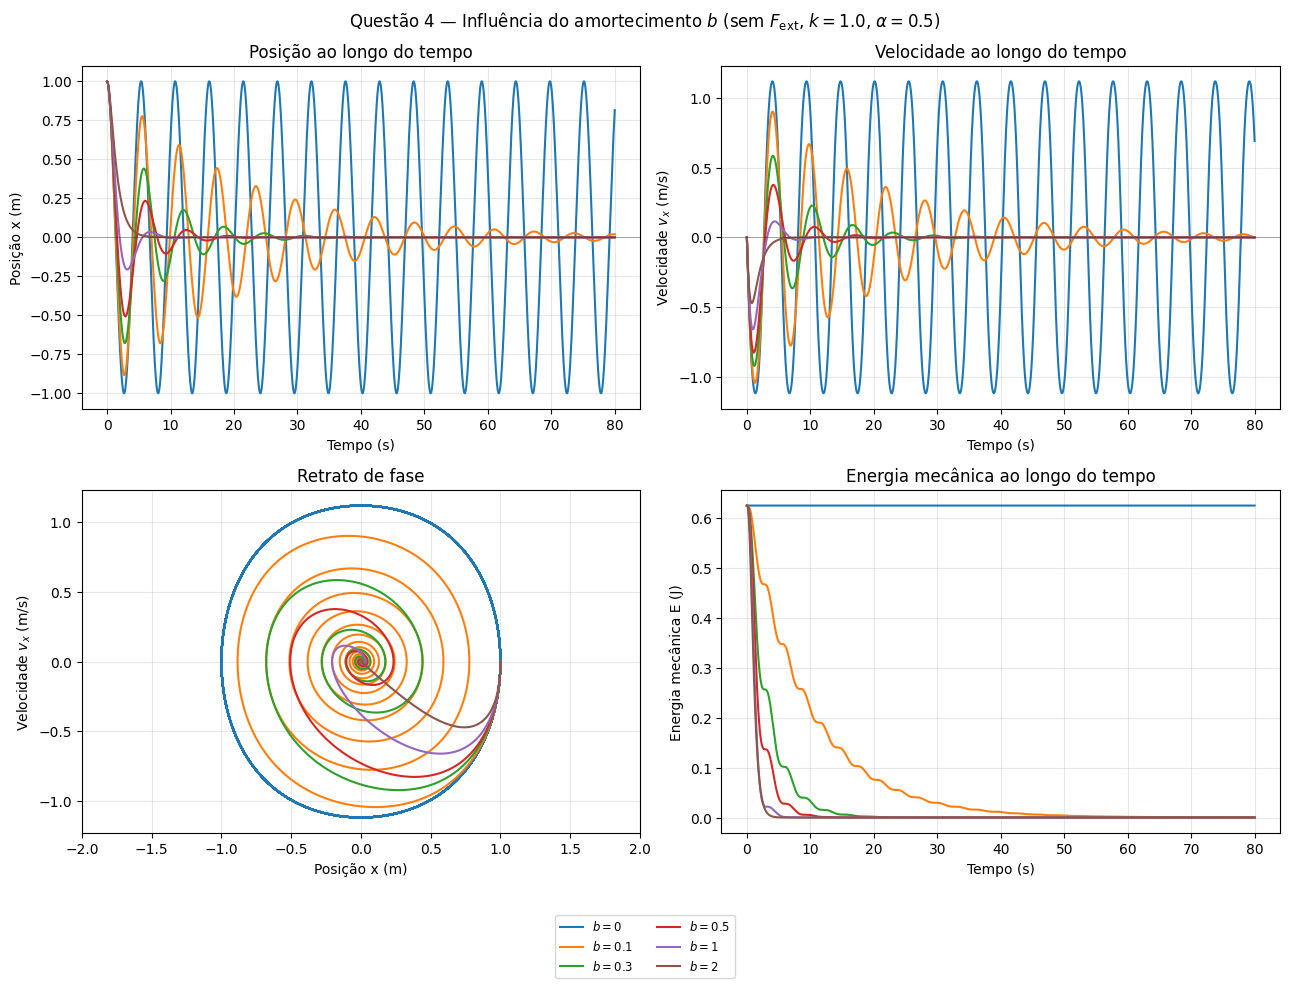

['outputs\\figures\\questao4_variacao_b.pdf']

In [63]:
# Questão 4: influência do amortecimento b (sem força externa, F₀ = 0)
T_MAX_Q4 = 80.0  # [s] — mais longo para ver o decaimento completo em b pequeno
b_values_q4 = [0.0, 0.1, 0.3, 0.5, 1.0, 2.0]

sims_q4 = [
    OscillatorPlot(
        label=rf'$b = {b_val:.2g}$',
        result=simulate_oscillator(b=b_val, with_external=False, t_max=T_MAX_Q4),
    )
    for b_val in b_values_q4
]

fig_q4, axes_q4 = plot_oscillator_panels(
    sims_q4,
    suptitle=(
        rf'Questão 4 — Influência do amortecimento $b$'
        rf' (sem $F_\mathrm{{ext}}$, $k={K}$, $\alpha={ALPHA}$)'
    ),
)

export_figure(fig_q4, 'questao4_variacao_b')

### Questão 5
Compare os resultados obtidos para $\alpha = 0$ (oscilador harmônico linear) e $\alpha \neq 0$ (oscilador não linear). Discuta quais características do movimento são exclusivamente devidas à não linearidade.

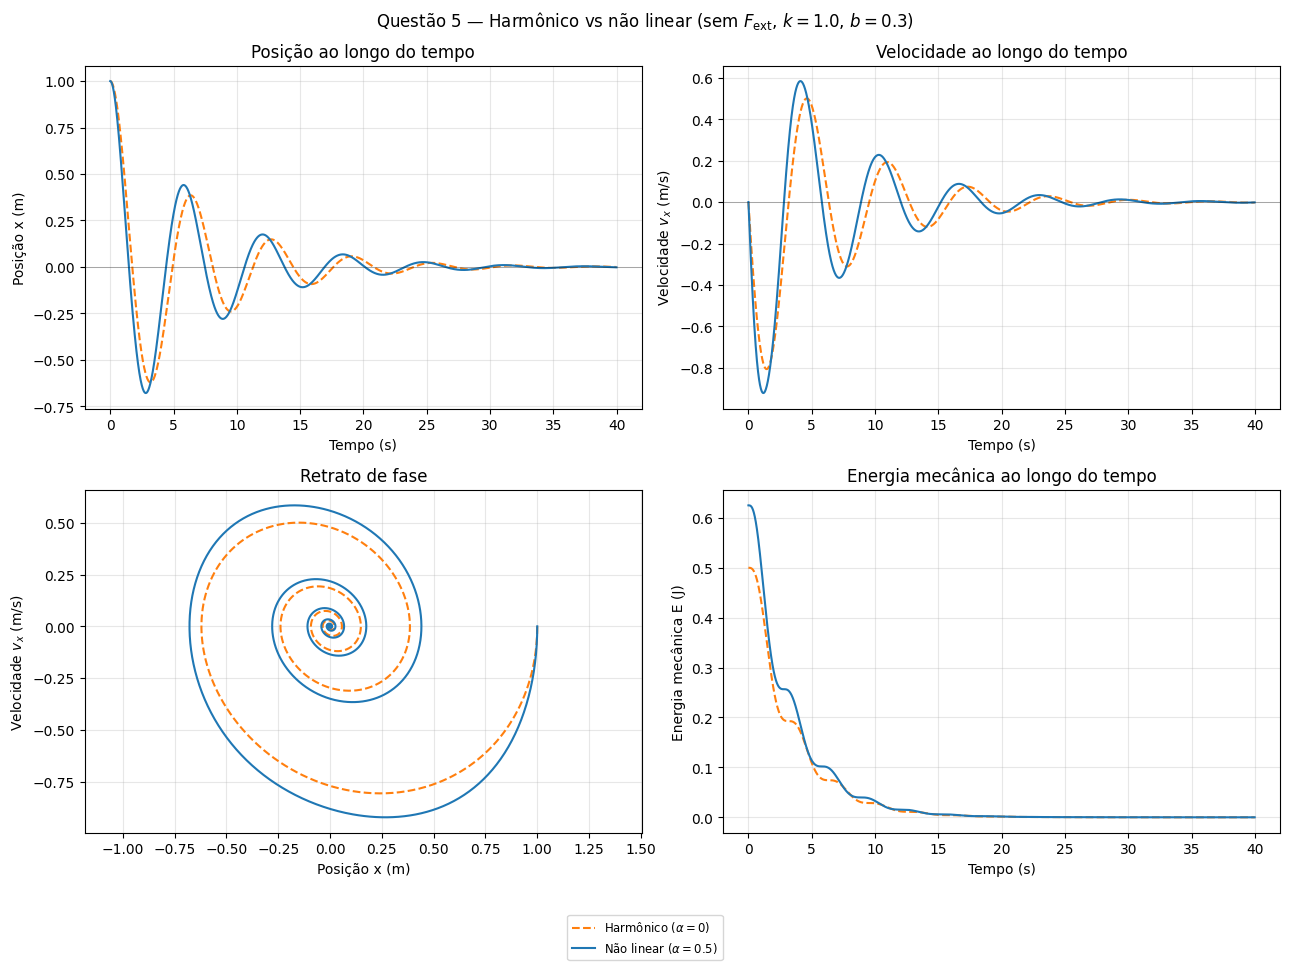

['outputs\\figures\\questao5_linear_vs_nao_linear.pdf']

In [64]:
# Questão 5: oscilador harmônico (α=0) vs não linear (α≠0), sem força externa
T_MAX_Q5 = 40.0  # [s]

sims_q5 = [
    OscillatorPlot(
        label=r'Harmônico ($\alpha = 0$)',
        result=simulate_oscillator(alpha=0.0, with_external=False, t_max=T_MAX_Q5),
        plot_style={'linestyle': '--', 'color': 'C1'},
    ),
    OscillatorPlot(
        label=rf'Não linear ($\alpha = {ALPHA}$)',
        result=simulate_oscillator(alpha=ALPHA, with_external=False, t_max=T_MAX_Q5),
        plot_style={'linestyle': '-', 'color': 'C0'},
    ),
]

fig_q5, axes_q5 = plot_oscillator_panels(
    sims_q5,
    suptitle=(
        rf'Questão 5 — Harmônico vs não linear'
        rf' (sem $F_\mathrm{{ext}}$, $k={K}$, $b={B}$)'
    ),
)

export_figure(fig_q5, 'questao5_linear_vs_nao_linear')

### Questão 6
Para o caso sem força externa ($F_0 = 0$), analise numericamente a evolução temporal da energia para diferentes valores do coeficiente de amortecimento $b$. Discuta a taxa de dissipação, o papel da não linearidade e a relação entre energia e trajetória no espaço de fase.

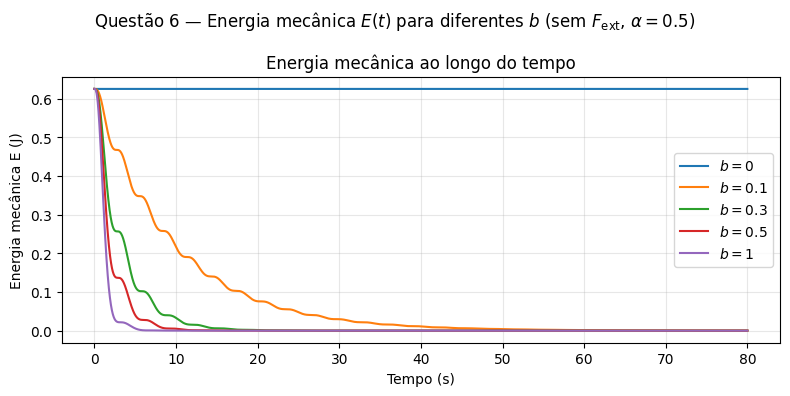

['outputs\\figures\\questao6_energia_variacao_b.pdf']

In [65]:
# Questão 6 — parte 1: taxa de dissipação de energia para diferentes b
T_MAX_Q6 = 80.0  # [s]
b_values_q6 = [0.0, 0.1, 0.3, 0.5, 1.0]

sims_q6_b = [
    OscillatorPlot(
        label=rf'$b = {b_val:.2g}$',
        result=simulate_oscillator(b=b_val, with_external=False, t_max=T_MAX_Q6),
    )
    for b_val in b_values_q6
]

fig_q6_e, ax_q6_e = plot_energy_per_time(sims_q6_b)
fig_q6_e.suptitle(
    rf'Questão 6 — Energia mecânica $E(t)$ para diferentes $b$ (sem $F_\mathrm{{ext}}$, $\alpha={ALPHA}$)',
    fontsize=12,
)
fig_q6_e.tight_layout()
plt.show()

export_figure(fig_q6_e, 'questao6_energia_variacao_b')

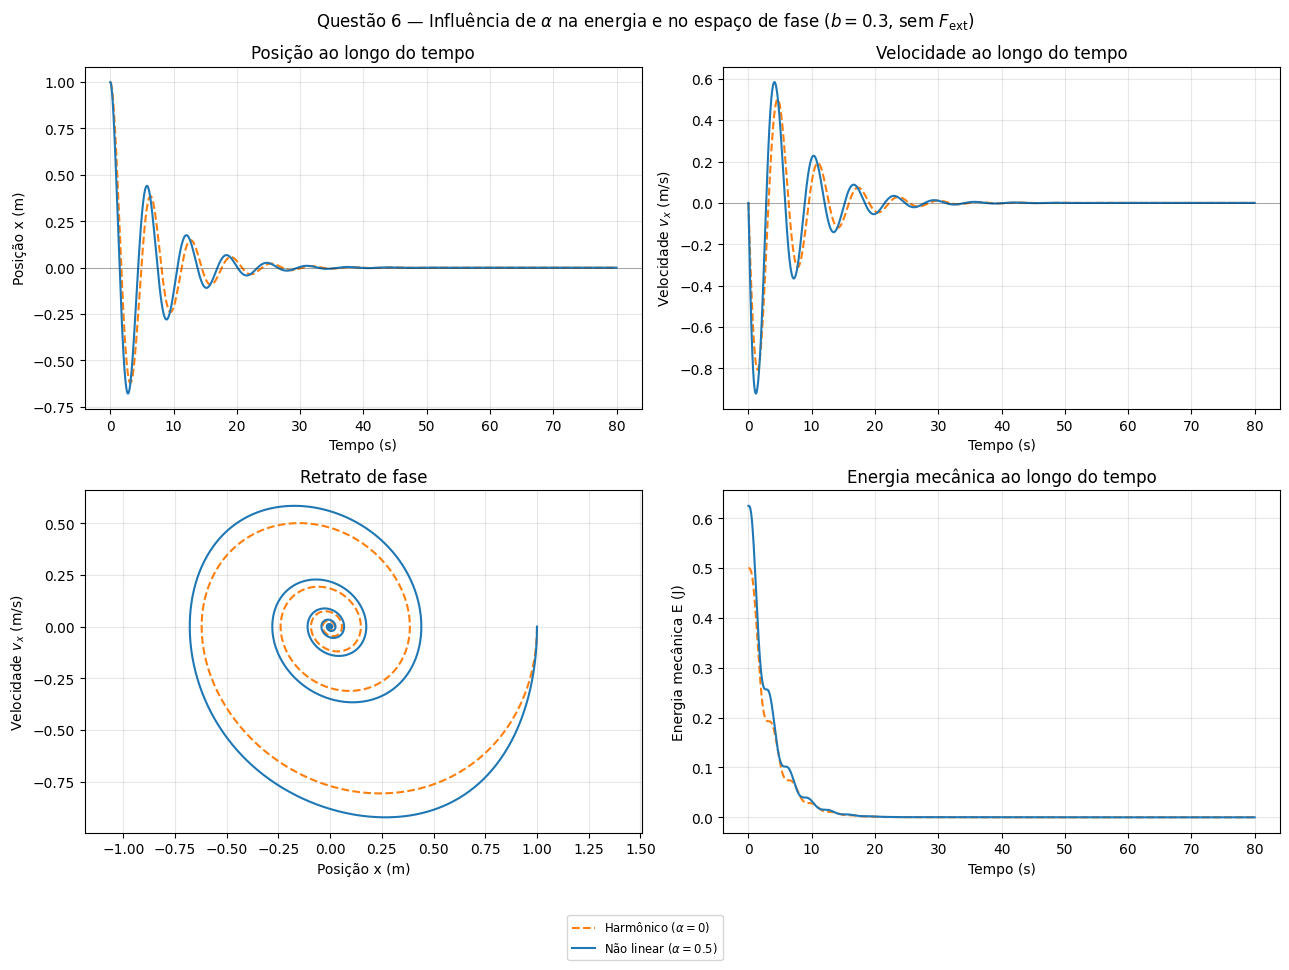

['outputs\\figures\\questao6_energia_nao_linearidade.pdf']

In [66]:
# Questão 6 — parte 2: papel da não linearidade na dinâmica energética e relação E(t) × espaço de fase
sims_q6_alpha = [
    OscillatorPlot(
        label=r'Harmônico ($\alpha = 0$)',
        result=simulate_oscillator(alpha=0.0, b=B, with_external=False, t_max=T_MAX_Q6),
        plot_style={'linestyle': '--', 'color': 'C1'},
    ),
    OscillatorPlot(
        label=rf'Não linear ($\alpha = {ALPHA}$)',
        result=simulate_oscillator(alpha=ALPHA, b=B, with_external=False, t_max=T_MAX_Q6),
        plot_style={'linestyle': '-', 'color': 'C0'},
    ),
]

fig_q6_panels, axes_q6_panels = plot_oscillator_panels(
    sims_q6_alpha,
    suptitle=(
        rf'Questão 6 — Influência de $\alpha$ na energia e no espaço de fase'
        rf' ($b={B}$, sem $F_\mathrm{{ext}}$)'
    ),
)

export_figure(fig_q6_panels, 'questao6_energia_nao_linearidade')

### Questão 7
Considere o caso com força externa periódica ($F_0 \neq 0$). Analise a resposta do sistema para diferentes valores de $\omega$, discutindo o comportamento transiente, o regime estacionário e a ocorrência de ressonância.

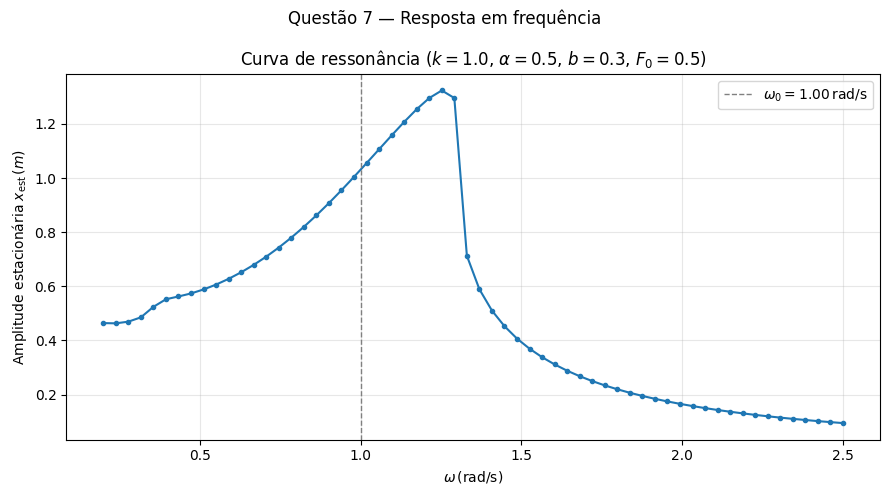

['outputs\\figures\\questao7_curva_ressonancia.pdf']

In [67]:
# Questão 7 — parte 1: curva de ressonância (varredura de ω)
OMEGA_NATURAL = float(np.sqrt(K / MASS))  # frequência natural linear ω₀ = √(k/m)
omega_values_q7 = np.linspace(0.2, 2.5, 60)

results_q7: list[OscillatorResults] = [
    simulate_oscillator(omega=float(w))
    for w in omega_values_q7
]

x_steady_q7 = [r.metrics.x_steady for r in results_q7]

fig_q7_res, ax_q7_res = plt.subplots(figsize=(9, 5))
ax_q7_res.plot(omega_values_q7, x_steady_q7, marker='o', markersize=3, linewidth=1.5, color='C0')
ax_q7_res.axvline(
    OMEGA_NATURAL, color='gray', linestyle='--', linewidth=1,
    label=rf'$\omega_0 = {OMEGA_NATURAL:.2f}\,$rad/s'
)
ax_q7_res.set_xlabel(r'$\omega\,(\mathrm{rad/s})$')
ax_q7_res.set_ylabel(r'Amplitude estacionária $x_\mathrm{est}\,(m)$')
ax_q7_res.set_title(rf'Curva de ressonância ($k={K}$, $\alpha={ALPHA}$, $b={B}$, $F_0={F0}$)')
ax_q7_res.legend()
ax_q7_res.grid(True, alpha=0.3)

fig_q7_res.suptitle(r'Questão 7 — Resposta em frequência', fontsize=12)
fig_q7_res.tight_layout()
plt.show()

export_figure(fig_q7_res, 'questao7_curva_ressonancia')

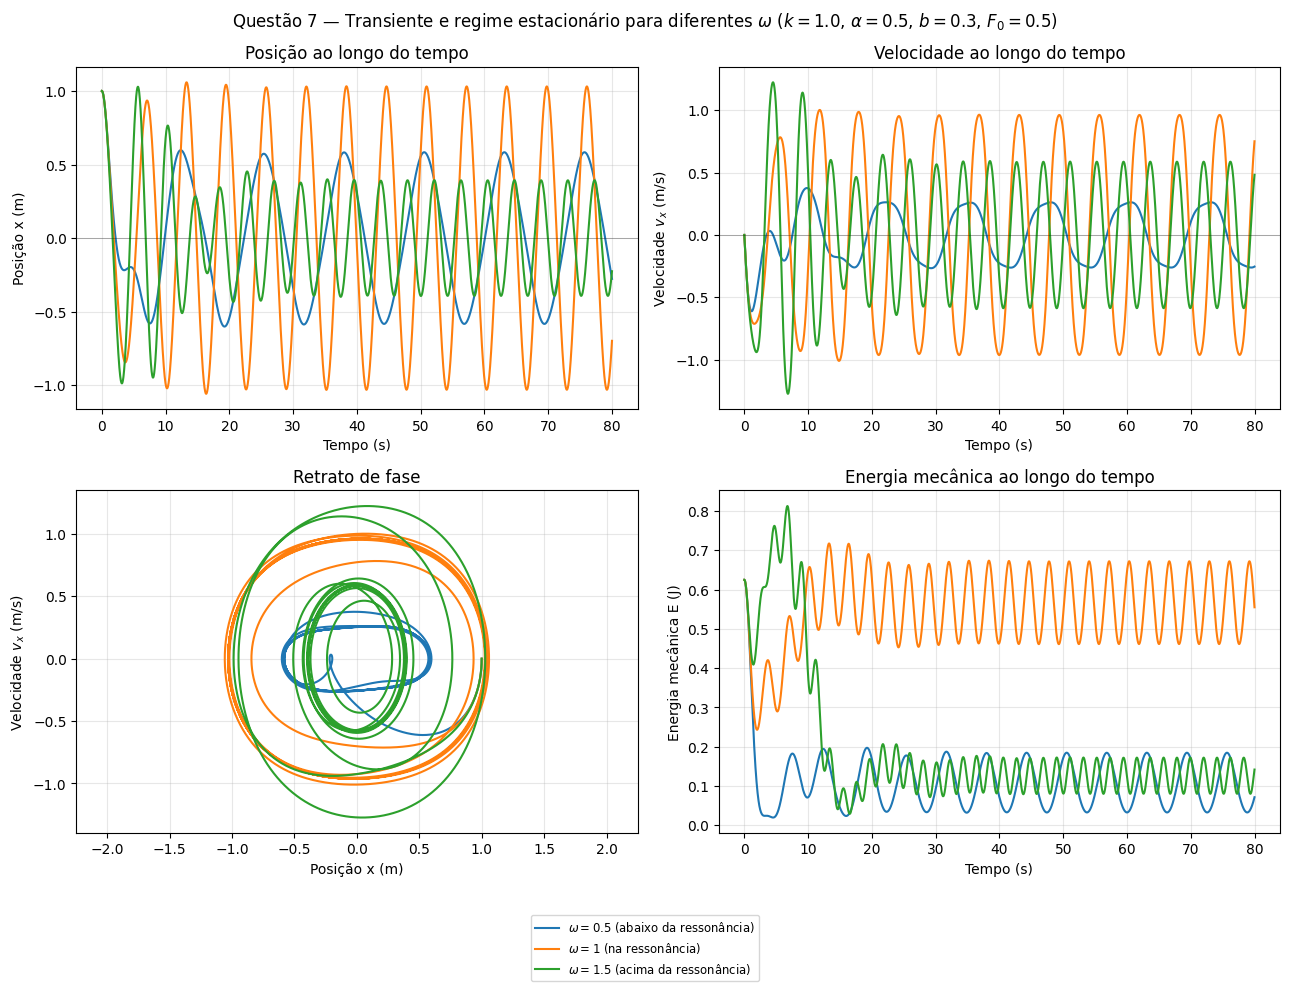

['outputs\\figures\\questao7_transiente_estacionario.pdf']

In [68]:
# Questão 7 — parte 2: transiente vs regime estacionário para ω específicos
omega_cases_q7 = [
    (0.5,          'abaixo da ressonância', 'C0'),
    (OMEGA_NATURAL, 'na ressonância',        'C1'),
    (1.5,          'acima da ressonância',  'C2'),
]

sims_q7_trans = [
    OscillatorPlot(
        label=rf'$\omega = {w:.2g}$ ({desc})',
        result=simulate_oscillator(omega=w),
        plot_style={'color': cor},
    )
    for w, desc, cor in omega_cases_q7
]

fig_q7_trans, axes_q7_trans = plot_oscillator_panels(
    sims_q7_trans,
    suptitle=(
        rf'Questão 7 — Transiente e regime estacionário para diferentes $\omega$'
        rf' ($k={K}$, $\alpha={ALPHA}$, $b={B}$, $F_0={F0}$)'
    ),
)

export_figure(fig_q7_trans, 'questao7_transiente_estacionario')

### Questão 8
Compare os resultados obtidos para o sistema forçado com $\alpha = 0$ (oscilador linear forçado) e $\alpha \neq 0$ (oscilador não linear forçado). Analise como a não linearidade modifica a amplitude, o comportamento temporal, o retrato de fase e a resposta na região de ressonância.

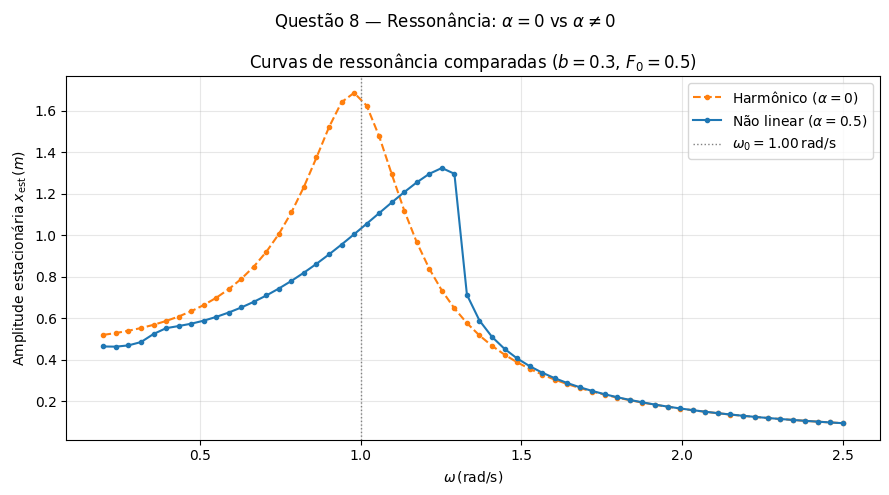

['outputs\\figures\\questao8_ressonancia_comparada.pdf']

In [69]:
# Questão 8 — parte 1: curvas de ressonância comparadas (α=0 vs α≠0)
omega_values_q8 = np.linspace(0.2, 2.5, 60)

results_q8_linear = [
    simulate_oscillator(omega=float(w), alpha=0.0)
    for w in omega_values_q8
]
results_q8_nonlinear = [
    simulate_oscillator(omega=float(w), alpha=ALPHA)
    for w in omega_values_q8
]

x_steady_linear    = [r.metrics.x_steady for r in results_q8_linear]
x_steady_nonlinear = [r.metrics.x_steady for r in results_q8_nonlinear]

fig_q8_res, ax_q8_res = plt.subplots(figsize=(9, 5))
ax_q8_res.plot(
    omega_values_q8, x_steady_linear,
    marker='o', markersize=3, linewidth=1.5,
    linestyle='--', color='C1', label=r'Harmônico ($\alpha = 0$)',
)
ax_q8_res.plot(
    omega_values_q8, x_steady_nonlinear,
    marker='o', markersize=3, linewidth=1.5,
    linestyle='-',  color='C0', label=rf'Não linear ($\alpha = {ALPHA}$)',
)
ax_q8_res.axvline(
    OMEGA_NATURAL, color='gray', linestyle=':', linewidth=1,
    label=rf'$\omega_0 = {OMEGA_NATURAL:.2f}\,$rad/s',
)
ax_q8_res.set_xlabel(r'$\omega\,(\mathrm{rad/s})$')
ax_q8_res.set_ylabel(r'Amplitude estacionária $x_\mathrm{est}\,(m)$')
ax_q8_res.set_title(rf'Curvas de ressonância comparadas ($b={B}$, $F_0={F0}$)')
ax_q8_res.legend()
ax_q8_res.grid(True, alpha=0.3)

fig_q8_res.suptitle(r'Questão 8 — Ressonância: $\alpha = 0$ vs $\alpha \neq 0$', fontsize=12)
fig_q8_res.tight_layout()
plt.show()

export_figure(fig_q8_res, 'questao8_ressonancia_comparada')

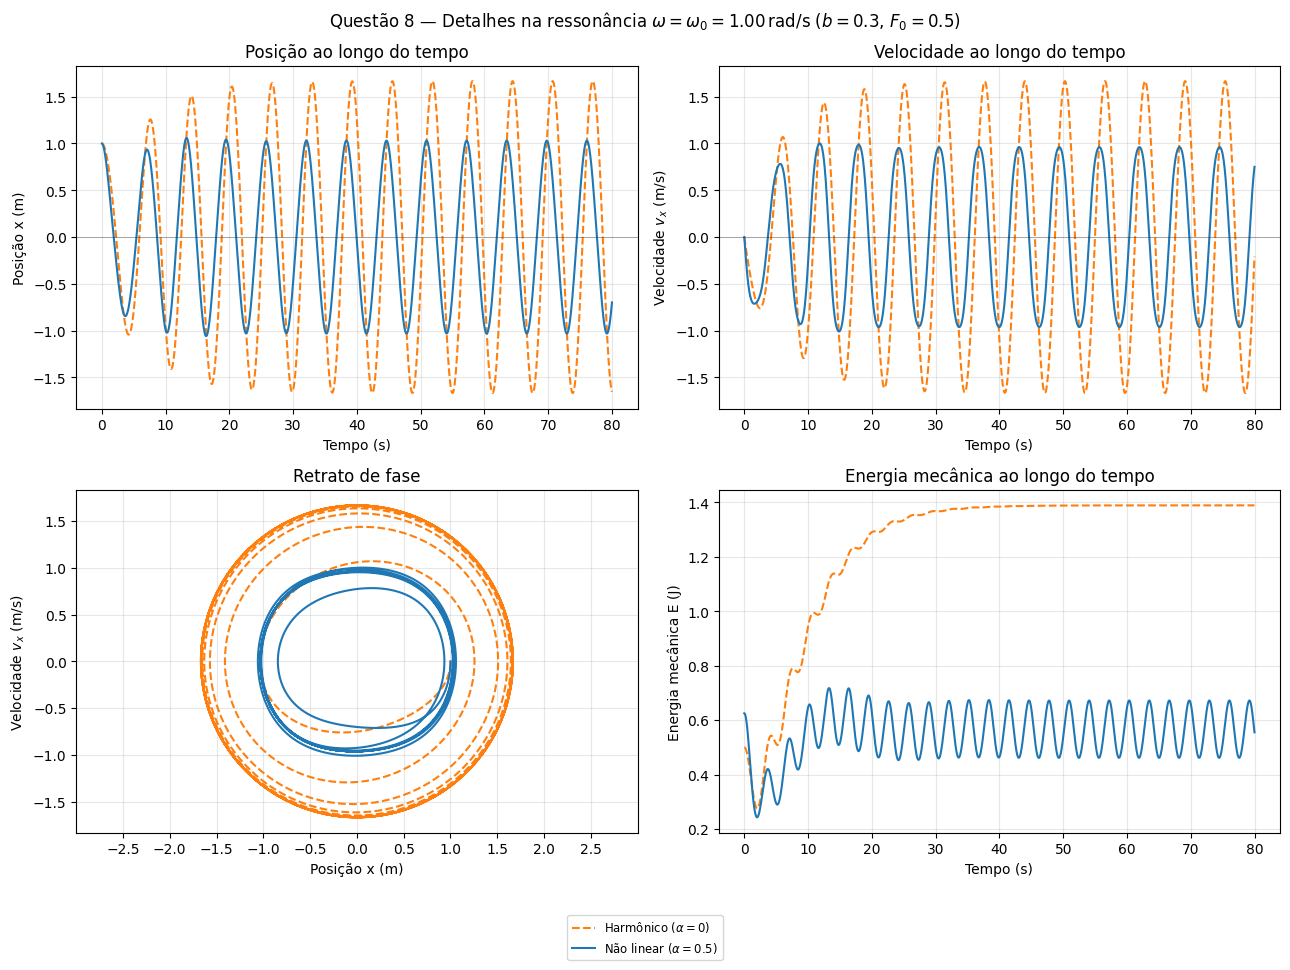

['outputs\\figures\\questao8_detalhe_ressonancia.pdf']

In [70]:
# Questão 8 — parte 2: comparação detalhada na ressonância (ω = ω₀)
sims_q8_detail = [
    OscillatorPlot(
        label=r'Harmônico ($\alpha = 0$)',
        result=simulate_oscillator(omega=OMEGA_NATURAL, alpha=0.0),
        plot_style={'linestyle': '--', 'color': 'C1'},
    ),
    OscillatorPlot(
        label=rf'Não linear ($\alpha = {ALPHA}$)',
        result=simulate_oscillator(omega=OMEGA_NATURAL, alpha=ALPHA),
        plot_style={'linestyle': '-', 'color': 'C0'},
    ),
]

fig_q8_detail, axes_q8_detail = plot_oscillator_panels(
    sims_q8_detail,
    suptitle=(
        rf'Questão 8 — Detalhes na ressonância $\omega = \omega_0 = {OMEGA_NATURAL:.2f}\,$rad/s'
        rf' ($b={B}$, $F_0={F0}$)'
    ),
)

export_figure(fig_q8_detail, 'questao8_detalhe_ressonancia')

### Questão 9
Para o caso com força externa periódica ($F_0 \neq 0$), analise a evolução temporal da energia mecânica. Discuta o balanço entre energia injetada e energia dissipada, a existência de um regime estacionário dinâmico, a dependência desse regime com a frequência $\omega$ e a relação entre energia e ressonância.

$$P_{\mathrm{ext}}(t) = F_0\cos(\omega t)\,v(t) \qquad P_{\mathrm{diss}}(t) = -bv^2(t)$$

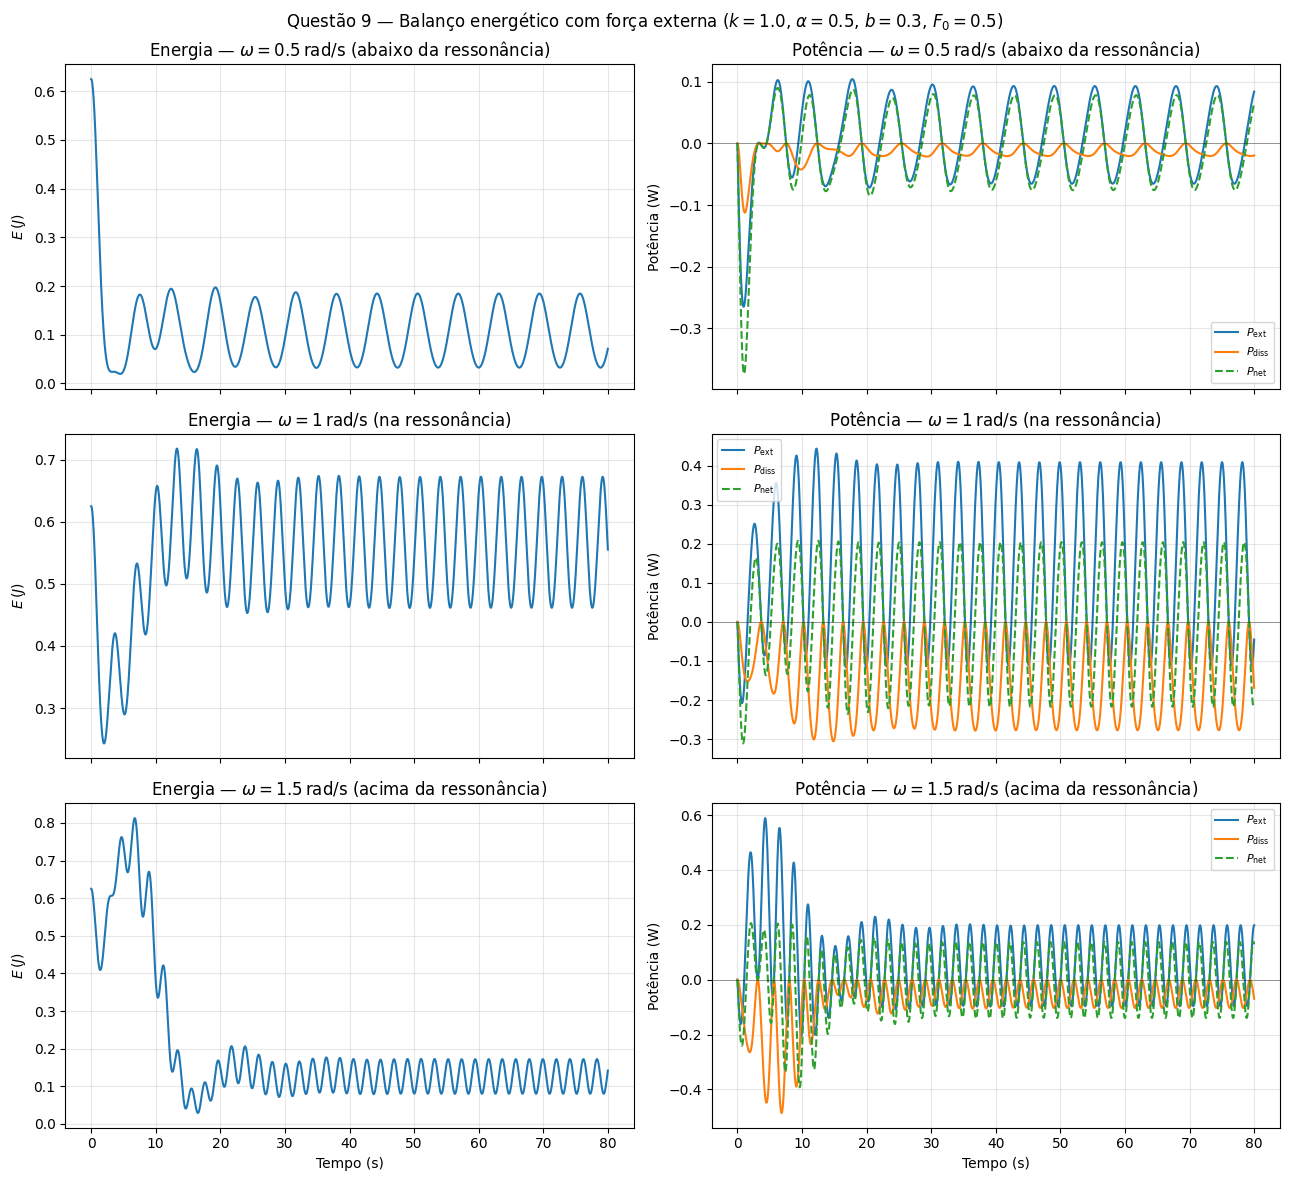

['outputs\\figures\\questao9_balanco_energetico.pdf']

In [71]:
# Questão 9: balanço energético com força externa para diferentes ω
omega_q9_cases = [
    (0.5,          'abaixo da ressonância'),
    (OMEGA_NATURAL, 'na ressonância'),
    (1.5,          'acima da ressonância'),
]

fig_q9, axes_q9 = plt.subplots(3, 2, figsize=(13, 12), sharex=True)

for row, (omega_val, desc) in enumerate(omega_q9_cases):
    result = simulate_oscillator(omega=omega_val)
    p_net = result.p_ext + result.p_diss

    # Energia mecânica
    axes_q9[row, 0].plot(result.times, result.energies, color='C0')
    axes_q9[row, 0].set_ylabel(r'$E\,(J)$')
    axes_q9[row, 0].set_title(rf'Energia — $\omega = {omega_val:.2g}\,$rad/s ({desc})')
    axes_q9[row, 0].grid(True, alpha=0.3)

    # Balanço de potência
    axes_q9[row, 1].plot(result.times, result.p_ext,  color='C0', label=r'$P_\mathrm{ext}$')
    axes_q9[row, 1].plot(result.times, result.p_diss, color='C1', label=r'$P_\mathrm{diss}$')
    axes_q9[row, 1].plot(result.times, p_net,         color='C2', linestyle='--', label=r'$P_\mathrm{net}$')
    axes_q9[row, 1].axhline(0.0, color='black', linewidth=0.5, alpha=0.5)
    axes_q9[row, 1].set_ylabel(r'Potência (W)')
    axes_q9[row, 1].set_title(rf'Potência — $\omega = {omega_val:.2g}\,$rad/s ({desc})')
    axes_q9[row, 1].legend(fontsize=8)
    axes_q9[row, 1].grid(True, alpha=0.3)

axes_q9[-1, 0].set_xlabel('Tempo (s)')
axes_q9[-1, 1].set_xlabel('Tempo (s)')

fig_q9.suptitle(
    rf'Questão 9 — Balanço energético com força externa ($k={K}$, $\alpha={ALPHA}$, $b={B}$, $F_0={F0}$)',
    fontsize=12,
)
fig_q9.tight_layout()
plt.show()

export_figure(fig_q9, 'questao9_balanco_energetico')

### Questão Extra — Euler vs Runge-Kutta de 4ª Ordem

Esta questão não faz parte do enunciado original. O objetivo é explorar a diferença entre os dois métodos de integração disponíveis: o **Euler** (utilizado no projeto anterior) e o **Runge-Kutta de 4ª ordem (RK4)** (utilizado nesse projeto).

O cenário escolhido é o oscilador não linear **conservativo** ($b = 0$, $F_0 = 0$), onde a energia mecânica deve ser exatamente constante. Esse cenário amplifica as diferenças numéricas, pois qualquer variação em $E(t)$ é puramente um artefato do integrador.

Parâmetros da comparação:
- $x_0 = 2{,}0\,\text{m}$, $v_0 = 0$ (amplitude grande, regime não linear)
- $\Delta t = 0{,}1\,\text{s}$ (10× maior que o padrão, amplifica erros)
- $T = 200\,\text{s}$ (integração longa, acumula deriva de fase)
- Energia teórica exata: $E_0 = \frac{1}{2}kx_0^2 + \frac{1}{4}\alpha x_0^4 = 2{,}0 + 2{,}0 = 4{,}0\,\text{J}$

Energia teórica E₀ = 4.0000 J

Euler — erro max: 1.028e-01  |  erro médio: 5.103e-02
RK4   — erro max: 1.604e-03    |  erro médio: 8.012e-04

Relação (erro Euler / erro RK4): 63.7×


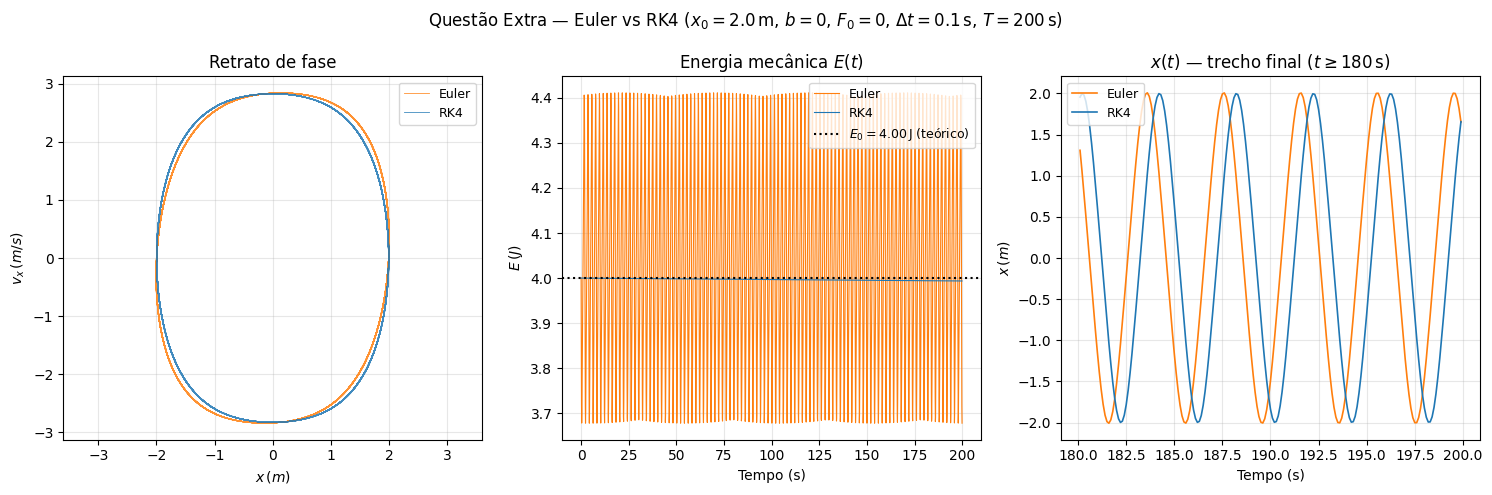

['outputs\\figures\\extra_euler_vs_rk4.pdf']

In [72]:
DT_COMP  = 0.10    # [s]  passo grande para amplificar diferenças numéricas
T_COMP   = 200.0   # [s]  integração longa para acumular deriva de fase
X0_COMP  = 2.0     # [m]  amplitude grande → regime fortemente não linear
particle_true_extra = Particle(MASS, Vec3(X0_COMP, 0.0, 0.0), Vec3(0.0, 0.0, 0.0))
E_TRUE   = oscillator_mechanical_energy(particle_true_extra, K, ALPHA)  # [J] energia teórica exata

result_euler_extra = simulate_oscillator(
    x0=X0_COMP, v0=0.0,
    with_damping=False, with_external=False,
    dt=DT_COMP, t_max=T_COMP,
    simulation_type="Euler",
)
result_rk4_extra = simulate_oscillator(
    x0=X0_COMP, v0=0.0,
    with_damping=False, with_external=False,
    dt=DT_COMP, t_max=T_COMP,
    simulation_type="RK4",
)

# ── Erros de energia ─────────────────────────────────────────────────────────
e_err_euler = np.abs(result_euler_extra.energies - E_TRUE) / E_TRUE
e_err_rk4   = np.abs(result_rk4_extra.energies   - E_TRUE) / E_TRUE

print(f"Energia teórica E₀ = {E_TRUE:.4f} J")
print()
print(f"Euler — erro max: {e_err_euler.max():.3e}  |  erro médio: {e_err_euler.mean():.3e}")
print(f"RK4   — erro max: {e_err_rk4.max():.3e}    |  erro médio: {e_err_rk4.mean():.3e}")
print(f"\nRelação (erro Euler / erro RK4): {e_err_euler.mean() / e_err_rk4.mean():.1f}×")

# ── Figura comparativa: 3 painéis ────────────────────────────────────────────
fig_extra, axes_extra = plt.subplots(1, 3, figsize=(15, 5))

colors = {'Euler': 'C1', 'RK4': 'C0'}
results_extra = [
    ('Euler', result_euler_extra),
    ('RK4',              result_rk4_extra),
]

# Painel 1: retrato de fase (trajetória completa)
for label, res in results_extra:
    x  = res.positions[:, 0]
    vx = res.velocities[:, 0]
    axes_extra[0].plot(x, vx, label=label, color=colors[label], linewidth=0.6, alpha=0.85)
axes_extra[0].set_xlabel(r'$x\,(m)$')
axes_extra[0].set_ylabel(r'$v_x\,(m/s)$')
axes_extra[0].set_title('Retrato de fase')
_apply_equal_phase_scale(axes_extra[0])
axes_extra[0].legend(fontsize=9)
axes_extra[0].grid(True, alpha=0.3)

# Painel 2: energia E(t)
for label, res in results_extra:
    axes_extra[1].plot(res.times, res.energies, label=label,
                       color=colors[label], linewidth=0.8)
axes_extra[1].axhline(E_TRUE, color='black', linestyle=':', linewidth=1.5,
                      label=rf'$E_0 = {E_TRUE:.2f}\,\mathrm{{J}}$ (teórico)')
axes_extra[1].set_xlabel('Tempo (s)')
axes_extra[1].set_ylabel(r'$E\,(J)$')
axes_extra[1].set_title(r'Energia mecânica $E(t)$')
axes_extra[1].legend(fontsize=9)
axes_extra[1].grid(True, alpha=0.3)

# Painel 3: x(t) no trecho final — deriva de fase acumulada
t_cut = T_COMP - 20.0
for label, res in results_extra:
    mask = res.times >= t_cut
    axes_extra[2].plot(res.times[mask], res.positions[mask, 0],
                       label=label, color=colors[label], linewidth=1.2)
axes_extra[2].set_xlabel('Tempo (s)')
axes_extra[2].set_ylabel(r'$x\,(m)$')
axes_extra[2].set_title(rf'$x(t)$ — trecho final ($t \geq {t_cut:.0f}\,\mathrm{{s}}$)')
axes_extra[2].legend(fontsize=9)
axes_extra[2].grid(True, alpha=0.3)

fig_extra.suptitle(
    rf'Questão Extra — Euler vs RK4'
    rf' ($x_0={X0_COMP}\,\mathrm{{m}}$, $b=0$, $F_0=0$,'
    rf' $\Delta t={DT_COMP}\,\mathrm{{s}}$, $T={T_COMP:.0f}\,\mathrm{{s}}$)',
    fontsize=12,
)
fig_extra.tight_layout()
plt.show()

export_figure(fig_extra, 'extra_euler_vs_rk4')